In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'C:\Users\Muhammad Taha\Desktop\Coffee Shop Sales Analysis.csv') 

In [3]:
print("First look at our data:")
print(df.head())
print("\n")

First look at our data:
       Product    Category  Cost  Price  March_Sales  April_Sales  \
0        Latte  Hot Coffee   1.2   4.50         3200         3680   
1   Cappuccino  Hot Coffee   1.1   4.25         2200         2400   
2    Americano  Hot Coffee   0.8   3.50         1800         1900   
3  Drip Coffee  Hot Coffee   0.5   2.75         1200         1100   
4     Espresso  Hot Coffee   0.6   3.00          900          950   

   March_Units  April_Units  
0          711          818  
1          518          565  
2          514          543  
3          436          400  
4          300          317  




In [4]:
total_march = df['March_Sales'].sum()
total_april = df['April_Sales'].sum()

In [5]:
total_growth = ((total_april - total_march) / total_march) * 100

In [6]:
print(f"Total March Sales: ${total_march:,.0f}")
print(f"Total April Sales: ${total_april:,.0f}")
print(f"Overall Growth: {total_growth:.1f}%")
print("\n")

Total March Sales: $25,050
Total April Sales: $29,210
Overall Growth: 16.6%




In [7]:
df['Growth'] = ((df['April_Sales'] - df['March_Sales']) / df['March_Sales']) * 100

In [8]:
df['Revenue_Share'] = (df['April_Sales'] / total_april) * 100

In [11]:
top_products = df.sort_values('April_Sales', ascending=False).head(5)
print("TOP 5 PRODUCTS BY APRIL SALES:")
print("=" * 40)
for index, row in top_products.iterrows():
    print(f"{row['Product']}: ${row['April_Sales']:,.0f} ({row['Revenue_Share']:.1f}% of total)")
print("\n")

TOP 5 PRODUCTS BY APRIL SALES:
Latte: $3,680 (12.6% of total)
Cappuccino: $2,400 (8.2% of total)
Breakfast Sandwich: $2,350 (8.0% of total)
Cold Brew: $2,200 (7.5% of total)
Iced Latte: $1,950 (6.7% of total)




In [12]:
growth_leaders = df[df['March_Sales'] > 500].sort_values('Growth', ascending=False).head(3)

print("FASTEST GROWING PRODUCTS:")
print("=" * 40)
for index, row in growth_leaders.iterrows():
    print(f"{row['Product']}: {row['Growth']:.1f}% growth")
print("\n")

FASTEST GROWING PRODUCTS:
Veggie Wrap: 20.8% growth
Scone: 20.0% growth
Coffee Beans: 20.0% growth




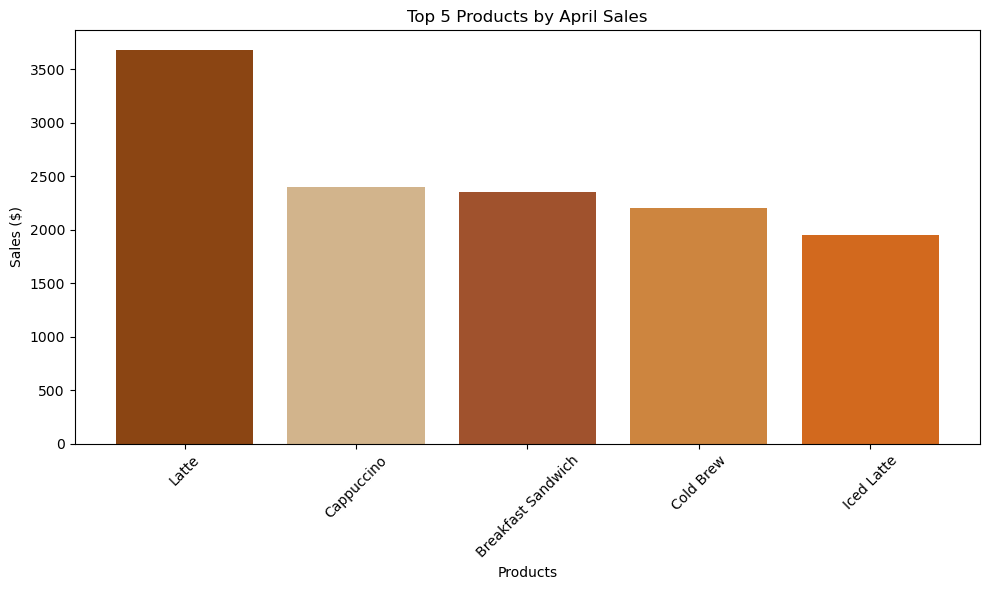

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(top_products['Product'], top_products['April_Sales'], color=['#8B4513', '#D2B48C', '#A0522D', '#CD853F', '#D2691E'])
plt.title('Top 5 Products by April Sales')
plt.xlabel('Products')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

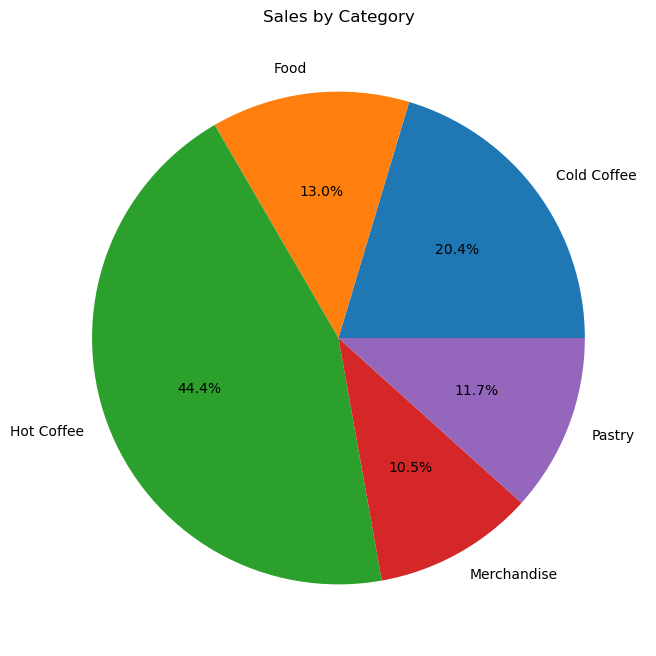

In [14]:
category_sales = df.groupby('Category')['April_Sales'].sum()
plt.figure(figsize=(8, 8))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%')
plt.title('Sales by Category')
plt.savefig('sales_by_category.png')
plt.show()

In [15]:
print("KEY INSIGHTS:")
print("=" * 40)
print(f"1. Our total sales grew by {total_growth:.1f}% from March to April")
print(f"2. The top selling product was {top_products.iloc[0]['Product']}")
print(f"3. The fastest growing product was {growth_leaders.iloc[0]['Product']}")
print(f"4. The {category_sales.idxmax()} category brings in the most revenue")

KEY INSIGHTS:
1. Our total sales grew by 16.6% from March to April
2. The top selling product was Latte
3. The fastest growing product was Veggie Wrap
4. The Hot Coffee category brings in the most revenue
